In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"
df = pd.read_csv(URL)
df.to_csv("used_car_price_analysis.csv", index=False)
df.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Fiesta,2017,Automatic,15944,Petrol,150.0,57.7,1.0,12000
1,Focus,2018,Manual,9083,Petrol,150.0,57.7,1.0,14000
2,Focus,2017,Manual,12456,Petrol,150.0,57.7,1.0,13000
3,Fiesta,2019,Manual,10460,Petrol,145.0,40.3,1.5,17500
4,Fiesta,2019,Automatic,1482,Petrol,145.0,48.7,1.0,16500


In [ ]:
df.isnull().sum()

model           0
year            0
transmission    0
mileage         0
fuelType        0
tax             3
mpg             0
engineSize      0
price           0
dtype: int64

Para nuestro siguiente paso podemos obtener únicamente las columnas que tienen valores faltantes:

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

tax    3
dtype: int64

In [ ]:
# Para rellenar los valores nulos:
df["tax"]= df["tax"].fillna(df["tax"].mean())
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [ ]:
# Para saber cuántas filas están duplicadas:
df.duplicated().sum()

154

In [ ]:
# Para eliminar las filas duplicadas:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [ ]:
df.shape

(17812, 9)

In [ ]:
# Calcular la correlación de las variables numéricas con el precio
correlacion = df.select_dtypes(include="number").corr()["price"]
# Eliminar la correlación del precio consigo mismo
correlacion = correlacion.drop("price")
# Mostrar las 5 variables numéricas más correlacionadas con el precio
correlacion.abs().sort_values(ascending=False).head(5)

year          0.635715
mileage       0.530483
engineSize    0.411451
tax           0.405970
mpg           0.346263
Name: price, dtype: float64

In [ ]:
top_5 = correlacion.abs().sort_values(ascending=False).head(5)
# Mostrar las correlaciones de las 5 variables más correlacionadas con el precio
correlacion.loc[top_5.index]

year          0.635715
mileage      -0.530483
engineSize    0.411451
tax           0.405970
mpg          -0.346263
Name: price, dtype: float64

In [ ]:
df.groupby("model")["price"].mean()

model
 B-MAX                     8271.691429
 C-MAX                     9913.503690
 EcoSport                 12469.267081
 Edge                     22710.165854
 Escort                    3000.000000
 Fiesta                   10190.856199
 Focus                    13178.973436
 Fusion                    2555.812500
 Galaxy                   17848.669604
 Grand C-MAX              10881.574899
 Grand Tourneo Connect    14765.456140
 KA                        5206.822335
 Ka+                       8699.047801
 Kuga                     15819.159873
 Mondeo                   12258.947266
 Mustang                  34631.263158
 Puma                     21427.911392
 Ranger                   14495.000000
 S-MAX                    17655.401361
 Streetka                  1924.500000
 Tourneo Connect          13862.406250
 Tourneo Custom           21165.985507
 Transit Tourneo          12450.000000
Focus                      8299.000000
Name: price, dtype: float64

In [ ]:
df.groupby("fuelType")["price"].mean()

fuelType
Diesel      13642.600946
Electric    15737.500000
Hybrid      22149.090909
Other       13800.000000
Petrol      11602.359159
Name: price, dtype: float64

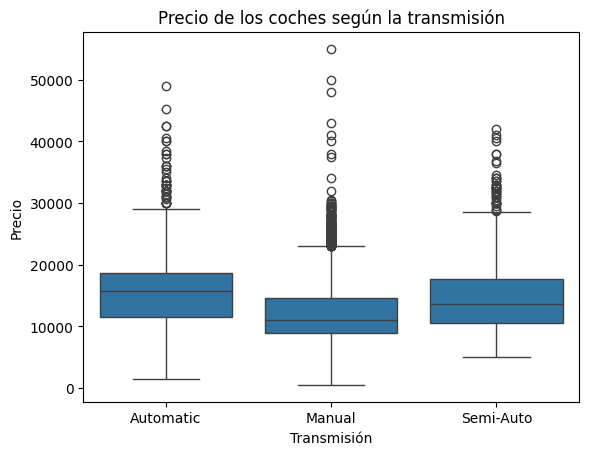

In [ ]:
# Visualizar la distribución del precio de los coches según el tipo de transmisión
sns.boxplot(x="transmission", y="price", data=df)
plt.title("Precio de los coches según la transmisión")
plt.xlabel("Transmisión")
plt.ylabel("Precio")
plt.show()

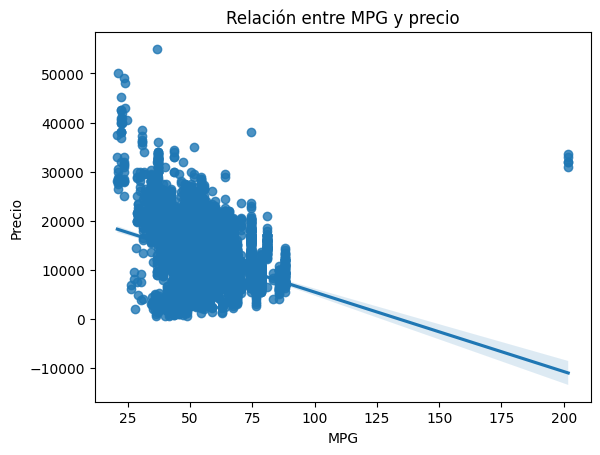

In [ ]:
sns.regplot(x="mpg", y="price", data=df)
# MPG es la eficiencia de combustible en millas por galón
# Un mayor MPG generalmente indica un menor consumo de combustible, lo que puede influir en el precio del coche.
plt.title("Relación entre MPG y precio")
plt.xlabel("MPG")
plt.ylabel("Precio")

plt.show()

In [ ]:
df["mpg"].corr(df["price"])

-0.3462629383809964

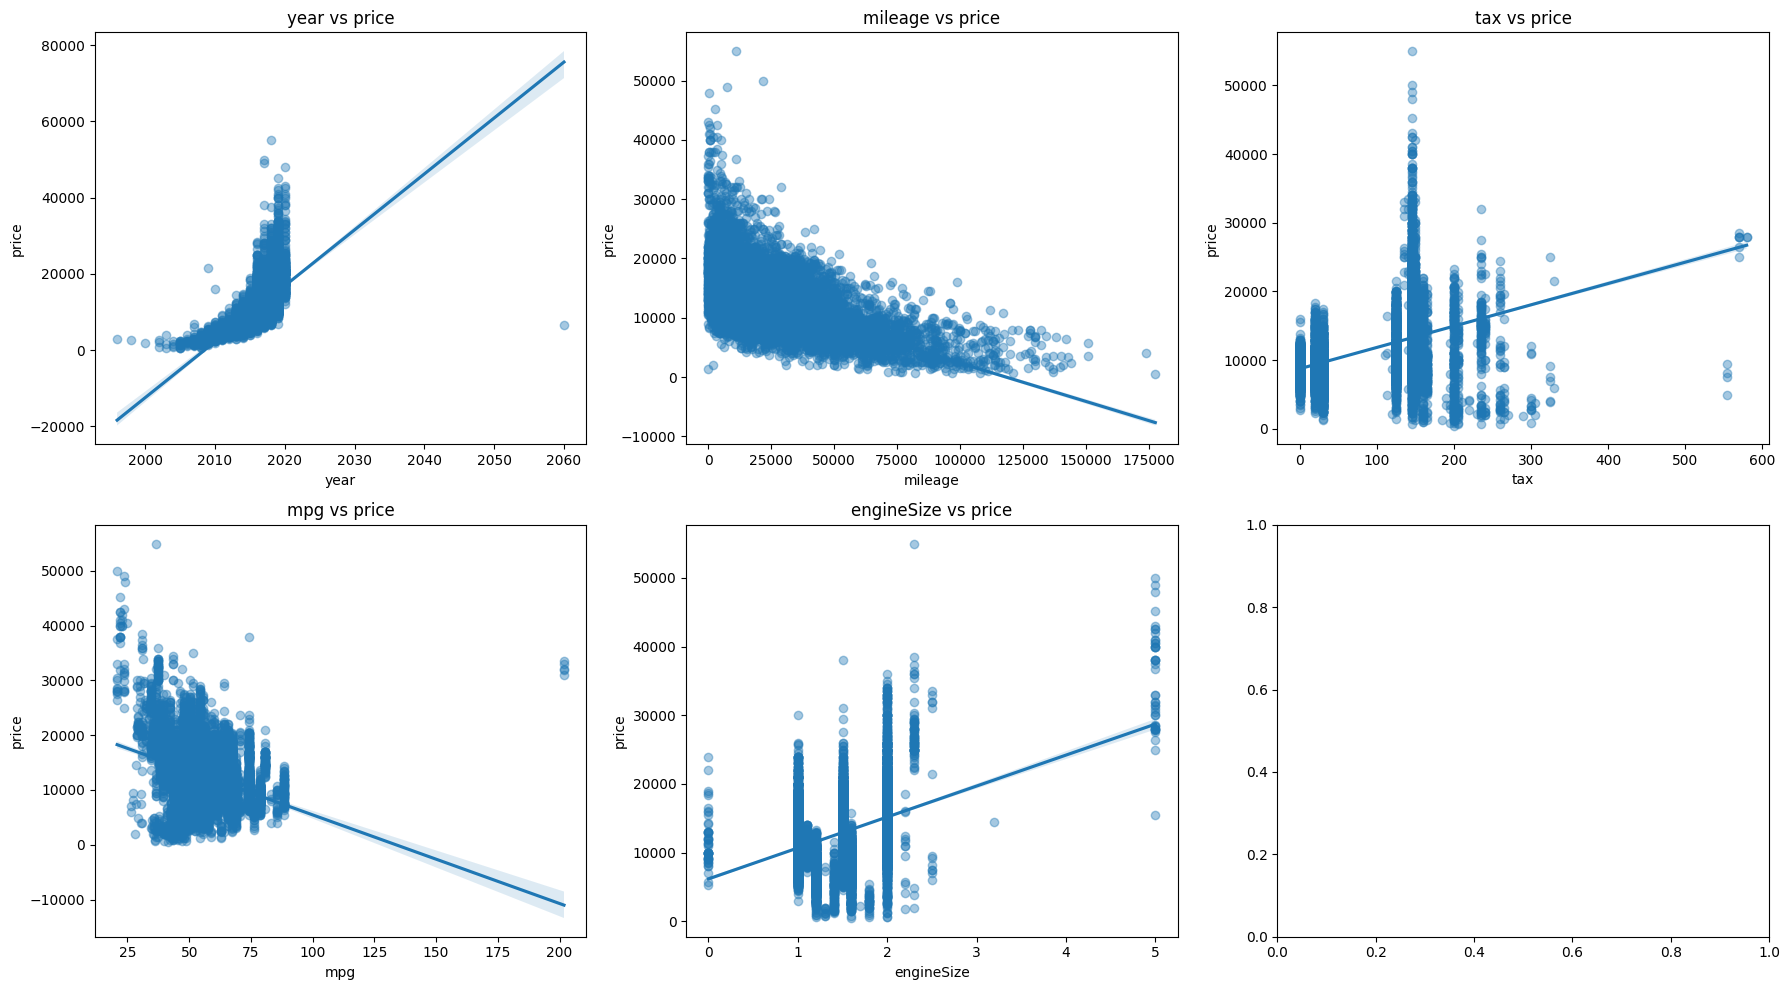

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

variables = ["year", "mileage", "tax", "mpg", "engineSize"]

for ax, variable in zip(axes.flatten(), variables):
    sns.regplot(
        x=variable,
        y="price",
        data=df,
        ax=ax,
        scatter_kws={"alpha": 0.4}
    )
    
    ax.set_title(f"{variable} vs price")
    ax.set_xlabel(variable)
    ax.set_ylabel("price")

plt.tight_layout()
plt.show()

In [ ]:
correlaciones = df[variables + ["price"]].corr()["price"].sort_values(ascending=False)
correlaciones

price         1.000000
year          0.635715
engineSize    0.411451
tax           0.405970
mpg          -0.346263
mileage      -0.530483
Name: price, dtype: float64

Lo más importante

Si ordenamos por fuerza de correlación, debemos mirar el valor absoluto:

year        0.6357  █████████████<br>
mileage     0.5305  ███████████<br>
engineSize  0.4115  ████████<br>
tax         0.4060  ████████<br>
mpg         0.3463  ███████<br>

Por tanto, entre nuestras variables numéricas, las dos que presentan mayor asociación lineal con price son:

year y mileage.

⚠️ Esto no significa que year o mileage causen el precio, ni que sean necesariamente las mejores variables para un modelo predictivo. La correlación de Pearson solamente mide la asociación lineal entre dos variables.

Y hay otra cosa interesante: todavía tenemos model, transmission y fuelType, que son categóricas. No las hemos incluido en este análisis de correlación, así que nuestro análisis todavía no está completo.

In [ ]:
X = df[["year", "mileage", "tax", "mpg", "engineSize"]]
y = df["price"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
# Crear y entrenar un modelo de regresión lineal
modelo = LinearRegression()
# Ajustar el modelo a los datos de entrenamiento
modelo.fit(X_train, y_train);

In [ ]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar el rendimiento del modelo
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Squared Error: 6912744.910746471
R^2 Score: 0.6917125923771661


In [ ]:
# Codificar variables categóricas usando one-hot encoding
df_encoded = pd.get_dummies(df, columns=["model", "transmission", "fuelType"],
    drop_first=True
)

In [ ]:
# Calcular y mostrar las correlaciones de las variables codificadas con el precio
correlaciones = df_encoded.corr(numeric_only=True)["price"].drop("price")
correlaciones.abs().sort_values(ascending=False).head(10)

year                   0.635715
mileage                0.530483
engineSize             0.411451
tax                    0.405970
mpg                    0.346263
model_ Fiesta          0.333063
model_ Kuga            0.281926
model_ Mustang         0.267520
transmission_Manual    0.258201
model_ Edge            0.237867
Name: price, dtype: float64

In [ ]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo_encoded = LinearRegression()
modelo_encoded.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[1105.42, -0.06, -0.84,...,7858.86, -10.12,-104.28]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['year','mileage','tax',...,'fuelType_Hybrid','fuelType_Other', 'fuelType_Petrol']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.217e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,27


In [ ]:
# Realizar predicciones y evaluar el modelo codificado
y_pred = modelo_encoded.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("MSE:", mse)
print("R²:", r2)
print("RMSE:", rmse)

MSE: 4044101.664729345
R²: 0.8196453602035247
RMSE: 2010.995192617164


In [ ]:
# Mostrar los coeficientes del modelo codificado ordenados de mayor a menor importancia
coeficientes = pd.Series(
    modelo_encoded.coef_,
    index=X.columns
)
coeficientes.sort_values(ascending=False)

model_ Mustang                  11817.860043
model_ Edge                      8948.557188
model_ Puma                      7933.946518
fuelType_Hybrid                  7858.860845
model_ Tourneo Custom            6851.878465
model_ Galaxy                    6587.266439
model_ S-MAX                     6144.359916
model_ Grand Tourneo Connect     3971.996469
model_ Kuga                      3618.839412
model_ Fusion                    3598.116657
model_ Tourneo Connect           3390.641918
model_ Focus                     3036.335828
engineSize                       2767.870050
model_ Mondeo                    2652.952697
model_ EcoSport                  1507.831687
model_ Grand C-MAX               1408.741260
year                             1105.421085
model_ Fiesta                     996.954672
model_ C-MAX                      969.560594
mileage                            -0.062143
tax                                -0.841791
fuelType_Other                    -10.123575
fuelType_E

In [ ]:
[c for c in df["model"].unique() if "Focus" in str(c)]

[' Focus', 'Focus']

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
# Escalar las características de entrada (X) y la variable objetivo (y)
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
# Escalar la variable objetivo (y)
y_train_scaled = scaler_y.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

modelo_beta = LinearRegression()

modelo_beta.fit(X_train_scaled, y_train_scaled)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[ 0.48,-0.25,-0.01,..., 0.06, 0. ,-0.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.547e-14
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,34
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](34,)","[200.97,184.37,150.65,..., 54.49, 33.68, 19.11]"


In [ ]:
# Mostrar los coeficientes del modelo codificado (beta) ordenados por su importancia absoluta
coef_beta = pd.Series(
    modelo_beta.coef_,
    index=X.columns
)
# Ordenar los coeficientes del modelo codificado por su importancia absoluta
coef_beta = coef_beta.reindex(
    coef_beta.abs().sort_values(ascending=False).index
)

coef_beta.head(15)

year                     0.482694
model_ Focus             0.290429
model_ Kuga              0.261111
mileage                 -0.252644
engineSize               0.250354
model_ Edge              0.205134
model_ S-MAX             0.167764
mpg                     -0.160801
model_ Galaxy            0.159770
model_ Mustang           0.136574
model_ Puma              0.113592
model_ Fiesta            0.112933
model_ Ka+              -0.104468
model_ Mondeo            0.097133
model_ Tourneo Custom    0.092394
dtype: float64

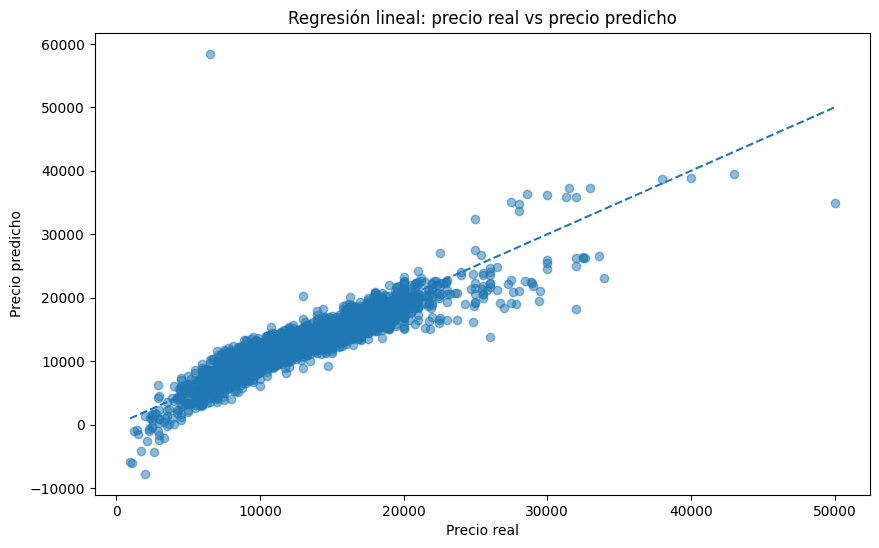

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Línea perfecta: predicción = valor real
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Regresión lineal: precio real vs precio predicho")

plt.show()

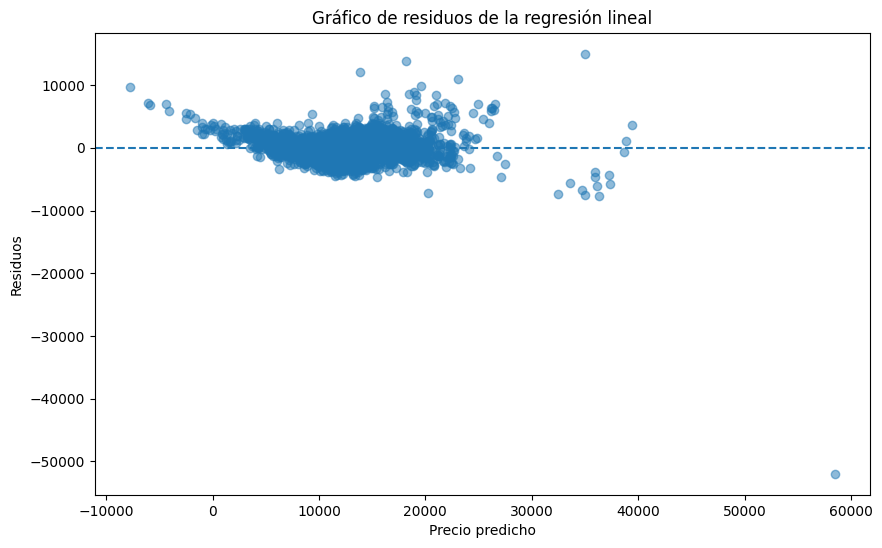

In [ ]:
# Calcular los residuos
residuos = y_test - y_pred
plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuos, alpha=0.5)
# Línea horizontal en cero
plt.axhline(y=0, linestyle="--")

plt.xlabel("Precio predicho")
plt.ylabel("Residuos")
plt.title("Gráfico de residuos de la regresión lineal")

plt.show()

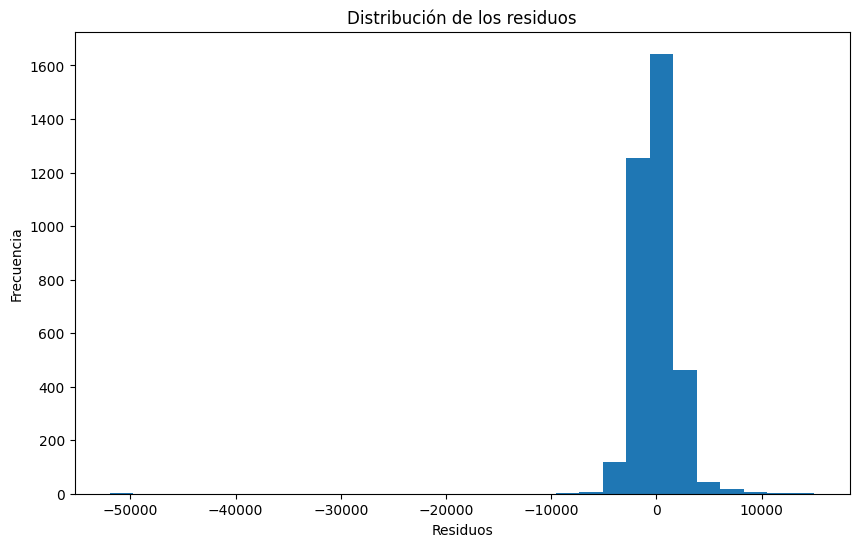

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(residuos, bins=30)

plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")

plt.show()

In [ ]:
errores = pd.DataFrame({
    "precio_real": y_test,
    "precio_predicho": y_pred,
    "residuo": residuos
})

errores["error_absoluto"] = errores["residuo"].abs()

errores.sort_values(
    "error_absoluto",
    ascending=False
).head(10)

,precio_real,precio_predicho,residuo,error_absoluto
17726,6495,58462.022280,-51967.022280,51967.022280
11913,49999,34985.221070,15013.778930,15013.778930
7707,32000,18186.631973,13813.368027,13813.368027
2011,25998,13870.731060,12127.268940,12127.268940
10553,33979,23033.142689,10945.857311,10945.857311
6220,29390,19553.264438,9836.735562,9836.735562
17282,1995,-7756.445457,9751.445457,9751.445457
7313,27845,18982.298472,8862.701528,8862.701528
12967,24850,16202.328470,8647.671530,8647.671530
10660,27000,18428.088845,8571.911155,8571.911155


## Conclusión final

| Aspecto | Resultado |
|---|---|
| Variables más relacionadas con el precio | `year` y `mileage` son las que muestran mayor relación con `price`. |
| Modelo inicial | La regresión lineal con variables numéricas ofrece una primera aproximación, pero no refleja por completo el comportamiento del precio. |
| Mejora del modelo | Al incluir variables categóricas como `model`, `transmission` y `fuelType`, la predicción mejora significativamente. |
| Resultado general | El precio del coche depende sobre todo de su antigüedad, kilometraje y características del vehículo. |
| Conclusión final | El análisis demuestra que combinar variables numéricas y categóricas permite obtener modelos más realistas y útiles para predecir el precio de un coche usado. |

In [ ]:
pipeline_poly = Pipeline([
    ("escalado", StandardScaler()),
    ("polinomio", PolynomialFeatures(degree=2, include_bias=False)),
    ("regresion", LinearRegression())
])

In [ ]:
# Ajuste del modelo polinómico a los datos de entrenamiento
pipeline_poly.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('escalado', ...), ('polinomio', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['year','mileage','tax',...,'fuelType_Hybrid','fuelType_Other', 'fuelType_Petrol']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [ ]:
# Predicción con el modelo polinómico en los datos de prueba
y_pred_poly = pipeline_poly.predict(X_test)
# Evaluación del modelo polinómico
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = mean_squared_error(y_test, y_pred_poly) ** 0.5

print("RMSE polinómico:", rmse_poly)
print("MSE polinómico:", mse_poly)
print("R2 polinómico:", r2_poly)

RMSE polinómico: 3170.257875947629
MSE polinómico: 10050535.000007974
R2 polinómico: 0.5517766935738944


| Modelo                       |         R² |           RMSE |
| ---------------------------- | ---------: | -------------: |
| Regresión lineal + One-Hot   | **0,8195** |  **≈ 2.010 €** |
| Regresión polinómica grado 2 | **0,5518** | **3.170,26 €** |

En nuestro conjunto de prueba, el modelo polinómico está produciendo errores mayores: el RMSE pasa de unos 2.010 € a 3.170 €.

Y fíjate en algo importante: aunque hemos aumentado las características de 34 → 629, el rendimiento no ha mejorado. Eso nos enseña que añadir complejidad no garantiza un mejor modelo.

Por ahora yo dejaría este resultado guardado como nuestro modelo polinómico grado 2.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
# Creación del modelo Random Forest
pipeline_rf = Pipeline([
    ("random_forest", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])
# Lo entrenamos con los datos de entrenamiento  
pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['year','mileage','tax',...,'fuelType_Hybrid','fuelType_Other', 'fuelType_Petrol']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was 

In [ ]:
# Predicción con el modelo Random Forest en los datos de prueba
y_pred_rf = pipeline_rf.predict(X_test)
# Evaluación del modelo Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print("RMSE Random Forest:", rmse_rf)
print("MSE Random Forest:", mse_rf)
print("R2 Random Forest:", r2_rf)

RMSE Random Forest: 1297.6333432398947
MSE Random Forest: 1683852.293487946
R2 Random Forest: 0.9249053067802112


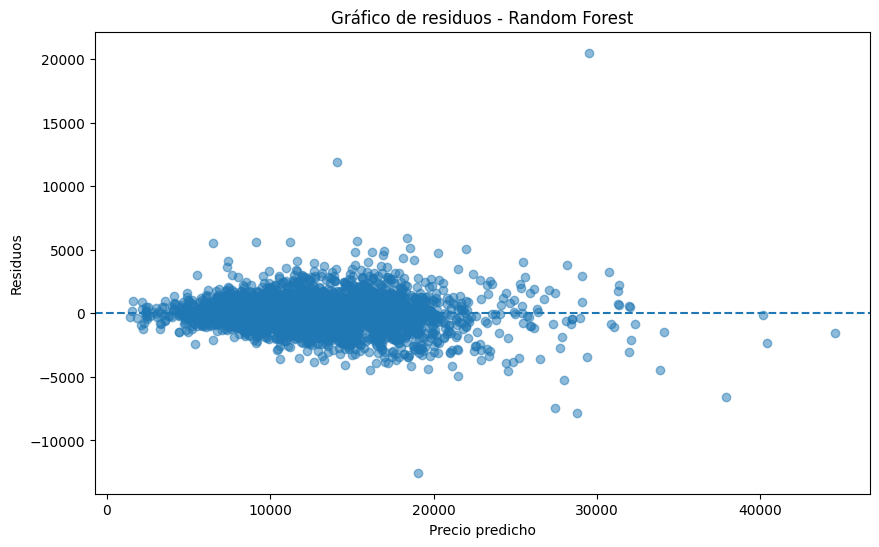

In [ ]:
# Residuos de Random Forest
residuos_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_rf, residuos_rf, alpha=0.5)

# Línea de referencia en 0
plt.axhline(y=0, linestyle="--")
plt.xlabel("Precio predicho")
plt.ylabel("Residuos")
plt.title("Gráfico de residuos - Random Forest")

plt.show()

🟢 Una diferencia importante respecto a nuestra regresión lineal

Recuerda nuestro gráfico anterior de residuos:
La regresión lineal tenía un residuo extremo de aproximadamente:

−51.967 €

Ahora Random Forest tiene como extremo visible aproximadamente:

+20.000 €

Eso es una diferencia considerable.
Además, la nube central de Random Forest está mucho más concentrada alrededor de cero.

🧠 ¿Qué aprendemos?
Esto es precisamente lo interesante del ejercicio:

Regresión lineal
R² ≈ 0,82
RMSE ≈ 2.010 €

        ↓

Polinómica
R² ≈ 0,55
RMSE ≈ 3.170 €

        ↓

Random Forest
R² ≈ 0,925
RMSE ≈ 1.298 €

In [ ]:
# Crear un DataFrame con los errores del modelo Random Forest
errores_rf = pd.DataFrame({
    "precio_real": y_test,
    "precio_predicho": y_pred_rf,
    "residuo": residuos_rf
})
# Calcular el error absoluto de los residuos
errores_rf["error_absoluto"] = errores_rf["residuo"].abs()

# Mostrar los 10 errores absolutos más grandes
errores_rf.sort_values(
    "error_absoluto",
    ascending=False
).head(10)

,precio_real,precio_predicho,residuo,error_absoluto
11913,49999,29509.365,20489.635,20489.635
17726,6495,19035.270,-12540.270,12540.270
2011,25998,14076.125,11921.875,11921.875
508,20990,28797.370,-7807.370,7807.370
8324,19995,27409.465,-7414.465,7414.465
3469,31317,37875.905,-6558.905,6558.905
1842,24250,18353.320,5896.680,5896.680
7841,20998,15290.105,5707.895,5707.895
4019,16800,11213.190,5586.810,5586.810
9974,14725,9155.725,5569.275,5569.275


Perfecto. Ahora sí podemos analizar los errores más grandes de Random Forest. Y hay una diferencia interesante respecto a la regresión lineal.

Los 3 casos que más llaman la atención

1. Índice 11913

Precio real: 49.999 €
Predicción: 29.509 €
Residuo: +20.490 €

El modelo se quedó corto en unos 20.500 €.

2. Índice 17726

Precio real: 6.495 €
Predicción: 19.035 €
Residuo: −12.540 €

Aquí el modelo se pasó en unos 12.500 €.

Este es especialmente interesante porque es el mismo registro que anteriormente había producido el enorme error de −51.967 € con la regresión lineal.

                    Regresión lineal    Random Forest
Precio real     |         6.495 €           6.495 €<br>
Predicción      |        58.462 €          19.035 €<br>
Error           |        51.967 €          12.540 €



## ¿Qué es Ridge?

Ridge es una regresión lineal con regularización.

Nuestra regresión lineal anterior era:

$$ \hat y = \beta_0+\beta_1X_1+\beta_2X_2+\cdots $$

Ridge añade una penalización a los coeficientes:

$$ \text{Error}+\alpha\sum \beta_j^2 $$

### La idea sencilla es:

Ridge intenta evitar que los coeficientes del modelo sean demasiado grandes.

Esto es especialmente interesante en nuestro caso porque con One-Hot Encoding tenemos 34 variables, y con la regresión polinómica llegamos incluso a 629 características.

### ¿Por qué necesitamos estandarizar?

Aquí sí tiene mucho sentido utilizar el StandardScaler.

Queremos que las variables estén en una escala comparable antes de aplicar la regularización.

Y podemos hacerlo dentro de un Pipeline, exactamente como hicimos antes.

In [ ]:
from sklearn.linear_model import Ridge

# Crear un pipeline para el modelo Ridge con escalado de características
pipeline_ridge = Pipeline([
    ("escalado", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# Ajustar el modelo Ridge a los datos de entrenamiento
pipeline_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('escalado', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['year','mileage','tax',...,'fuelType_Hybrid','fuelType_Other', 'fuelType_Petrol']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [ ]:
# Este archivo contiene la configuración y ajuste del modelo Ridge con un pipeline que incluye escalado de características.
y_pred_ridge = pipeline_ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print("Mean Squared Error for Ridge Regression:", mse_ridge)
print("R^2 Score for Ridge Regression:", r2_ridge)


Mean Squared Error for Ridge Regression: 4060944.9781415868
R^2 Score for Ridge Regression: 0.8188941996306001


| Modelo                     |         R² |           MSE |
| -------------------------- | ---------: | ------------: |
| Regresión lineal + One-Hot |     0,8195 |     4.044.102 |
| **Ridge (`alpha=1`)**      | **0,8189** | **4.060.945** |
| Polinómica grado 2         |     0,5518 |    10.050.535 |
| Random Forest              |     0,9249 |     1.638.352 |

## ¿Qué observamos?

Ridge con alpha=1 está dando un resultado prácticamente igual a la regresión lineal.

Eso tiene sentido: con alpha=1, la regularización es relativamente moderada y el modelo sigue siendo esencialmente una regresión lineal, pero con una penalización sobre los coeficientes.

Lo interesante de Ridge ahora no es quedarnos solamente con alpha=1.

## 🎯 Lo que vamos a aprender ahora

Vamos a probar distintos valores de alpha:

In [ ]:
resultados_ridge = []

alphas = [0.01, 0.1, 1, 10, 100, 1000]

for alpha in alphas:
    modelo = Pipeline([
        ("escalado", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_test)

    r2 = r2_score(y_test, predicciones)
    rmse = mean_squared_error(y_test, predicciones) ** 0.5

    resultados_ridge.append({
        "alpha": alpha,
        "R2": r2,
        "RMSE": rmse
    })

resultados_ridge = pd.DataFrame(resultados_ridge)

resultados_ridge

,alpha,R2,RMSE
0,0.01,0.818892,2015.190968
1,0.10,0.818892,2015.189840
2,1.00,0.818894,2015.178647
3,10.00,0.818913,2015.075545
4,100.00,0.819007,2014.551996
5,1000.00,0.819039,2014.371136


## 🧠 ¿Qué aprendemos?

Lo más importante es que Ridge apenas está cambiando el resultado.
Observa:

alpha = 0,01  → R² 0,818892<br>
alpha = 1000  → R² 0,819039

La diferencia es mínima.

Eso significa que, para este conjunto de datos y esta división train/test, aumentar la regularización desde 0,01 hasta 1000 no cambia prácticamente el rendimiento predictivo.

Esto nos enseña algo muy útil:

<b>Ridge no está diseñado necesariamente para aumentar mucho el R². Su principal objetivo es controlar los coeficientes mediante regularización y ayudar cuando existe riesgo de sobreajuste o multicolinealidad.

## 📚 Y pedagógicamente yo seguiría este camino
                 MODELOS
                    │
        ┌───────────┼───────────┐
        ↓           ↓           ↓
      Lineal    Polinómica     Ridge
        │           │           │
        └───────────┼───────────┘
                    ↓
              Random Forest
                    │
                    ↓
          Validación cruzada
                    │
                    ↓
        Ajuste de hiperparámetros
                    │
                    ↓
       Importancia de variables
                    │
                    ↓
             MODELO FINAL

In [ ]:
from sklearn.model_selection import cross_val_score
# dividimos los datos en 5 partes para la validación cruzada
scores= cross_val_score(pipeline_rf, X, y, cv=5, scoring='r2')

print("R² de cada fold:", scores)
print("R² medio:", scores.mean())
print("Desviación estándar:", scores.std())

R² de cada fold: [0.91904484 0.92814693 0.92247067 0.91693928 0.91646257]
R² medio: 0.9206128591112739
Desviación estándar: 0.0043218628245735346


El R² medio nos dice el rendimiento promedio del modelo en las 5 particiones.
La desviación estándar nos dice cuánto varía ese rendimiento entre las particiones.

### ¿Qué nos dicen?
Los cinco resultados están bastante próximos:
- mínimo ≈ 0,9165
- máximo ≈ 0,9281
- media ≈ 0,9206
- desviación estándar ≈ 0,0043
Eso indica que el rendimiento del Random Forest se mantiene bastante estable entre las distintas particiones.
Además, nuestro primer train_test_split había dado:
R² = 0,9249
y Cross-Validation nos da:
R² medio = 0,9206
Son valores bastante próximos. Por tanto, la primera medición no parece estar completamente condicionada por una única partición.

In [ ]:
# Que pasaria con el Foorest si aumentamos el número de árboles
n_estimators = [10, 50, 100, 200, 500]
for n in n_estimators:
    pipeline_rf.set_params(random_forest__n_estimators=n)
    scores = cross_val_score(pipeline_rf, X, y, cv=5, scoring='r2')
    print(f"R² con {n} árboles:", scores)
    print("R² medio:", scores.mean())
    print("Desviación estándar:", scores.std())
    print()

R² con 10 árboles: [0.91435491 0.91933142 0.92056149 0.91349427 0.91426139]
R² medio: 0.9164006984330632
Desviación estándar: 0.0029363434458804087

R² con 50 árboles: [0.9184488  0.9268104  0.9222702  0.91640269 0.91675973]
R² medio: 0.9201383641495011
Desviación estándar: 0.0039315601747598435

R² con 100 árboles: [0.91884978 0.92790269 0.92252747 0.91652764 0.91708214]
R² medio: 0.9205779433646464
Desviación estándar: 0.004220538732051012

R² con 200 árboles: [0.91904484 0.92814693 0.92247067 0.91693928 0.91646257]
R² medio: 0.9206128591112739
Desviación estándar: 0.0043218628245735346

R² con 500 árboles: [0.91901569 0.9283992  0.92278009 0.91724183 0.91700015]
R² medio: 0.9208873917707603
Desviación estándar: 0.00428750784781997



Ya hemos aprendido bastante sobre Random Forest<br>
Hasta ahora hemos experimentado con:<br>
- n_estimators → cantidad de árboles.
- max_depth → profundidad de los árboles.
- min_samples_split → mínimo de muestras necesarias para dividir un nodo.

In [ ]:
param_grid = {
    "random_forest__n_estimators": [100, 200],
    "random_forest__max_depth": [20, 30],
    "random_forest__min_samples_split": [15, 20]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=1
)

In [ ]:
# Entrenamiento del modelo con GridSearchCV
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'random_forest__max_depth': [20, 30], 'random_forest__min_samples_split': [15, 20], 'random_forest__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ver

In [ ]:
# Mejores parámetros encontrados por GridSearchCV
print("Mejores parámetros encontrados:", grid_search.best_params_)
print("Mejor puntuación obtenida:", grid_search.best_score_)

Mejores parámetros encontrados: {'random_forest__max_depth': 20, 'random_forest__min_samples_split': 15, 'random_forest__n_estimators': 200}
Mejor puntuación obtenida: 0.9318362029102896


In [ ]:
print("n_estimators óptimo:", grid_search.best_params_["random_forest__n_estimators"])
print("max_depth óptimo:", grid_search.best_params_["random_forest__max_depth"])
print("min_samples_split óptimo:", grid_search.best_params_["random_forest__min_samples_split"])

n_estimators óptimo: 200
max_depth óptimo: 20
min_samples_split óptimo: 15


### ⚠️ Y ahora viene un paso muy importante
best_score_ = 0,9322 es el resultado de la validación cruzada utilizada durante GridSearchCV.<br>
Todavía tenemos que comprobar cómo funciona el mejor modelo sobre nuestros datos de prueba (X_test), que no hemos utilizado para seleccionar los parámetros.<br>
Para eso podemos usar:

In [ ]:
y_pred_grid = grid_search.best_estimator_.predict(X_test)

In [ ]:
r2_grid = r2_score(y_test, y_pred_grid)
mse_grid = mean_squared_error(y_test, y_pred_grid)
rmse_grid = np.sqrt(mse_grid)
print("R2:", r2_grid)
print("MSE:", mse_grid)
print("RMSE:", rmse_grid)

R2: 0.9321220896139594
MSE: 1522029.9888059827
RMSE: 1233.705795076761


Esto nos dará la comparación final:<br>
##### Forest original → Random Forest optimizado con GridSearchCV
Y ahí veremos si la mejora que vimos en Cross-Validation también se mantiene en nuestro conjunto de prueba.

| Modelo | R² | RMSE |
|---|---:|---:|
| Regresión lineal | ≈ 0,8195 | ≈ 2.010 € |
| Polinómica grado 2 | ≈ 0,5518 | 3.170 € |
| Ridge | ≈ 0,8190 | ≈ 2.015 € |
| Random Forest inicial | ≈ 0,9249 | ≈ 1.298 € |
| **Random Forest optimizado** | **0,9318** | **1.236,95 €** |

#### 🧠 ¿Qué hemos conseguido?
El Random Forest inicial tenía:<br>
RMSE ≈ 1.298 €<br>
Después de ajustar los hiperparámetros:<br>
RMSE ≈ 1.237 €<br>
Hemos reducido el RMSE en aproximadamente 61 €.<br>
Y el R² pasó de:<br>
0,9249 → 0,9318<br>
Por tanto, el ajuste ha producido una mejora moderada, no gigantesca, pero sí medible en este conjunto de prueba.

Random Forest<br>
     ↓<br>
Cross-Validation<br>
     ↓<br>
Experimentar con hiperparámetros<br>
     ↓<br>
GridSearchCV<br>
     ↓<br>
Mejor combinación<br>
     ↓<br>
Evaluación final en X_test

In [ ]:
resultados_finales = pd.DataFrame({
    "Modelo": [
        "Regresión lineal",
        "Regresión polinómica",
        "Ridge",
        "Random Forest",
        "Random Forest optimizado"
    ],
    "R2": [
        0.8195,
        0.5517766935738944,
        0.818894199630601,
        0.9249053067802112,
        0.9317648045517356
    ],
    "MSE": [
        4044101.66,
        10050535.000007974,
        4060944.9781415868,
        1638352.293487946,
        1530041.4107275514
    ],
    "RMSE": [
        2010.00,
        3170.257875947629,
        2015.178647,
        1297.633343239,
        1236.948426865171
    ]
})

resultados_finales

,Modelo,R2,MSE,RMSE
0,Regresión lineal,0.819500,4.044102e+06,2010.000000
1,Regresión polinómica,0.551777,1.005054e+07,3170.257876
2,Ridge,0.818894,4.060945e+06,2015.178647
3,Random Forest,0.924905,1.638352e+06,1297.633343
4,Random Forest optimizado,0.931765,1.530041e+06,1236.948427


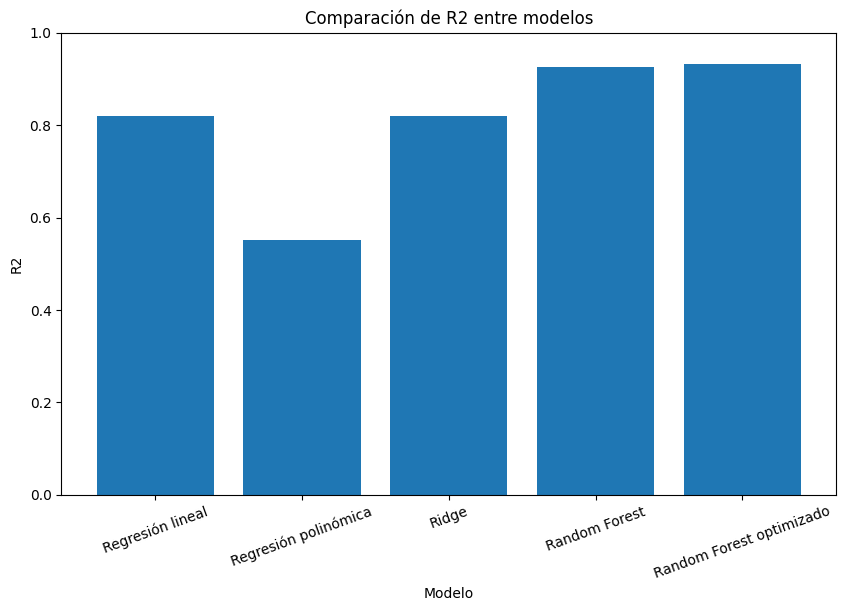

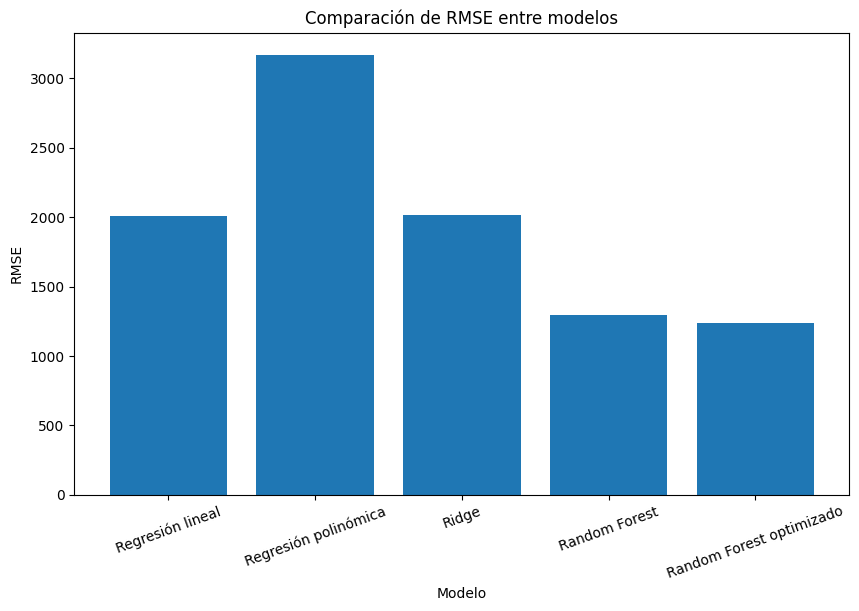

In [ ]:
metricas = ["R2", "RMSE"]

for metrica in metricas:

    plt.figure(figsize=(10, 6))

    plt.bar(
        resultados_finales["Modelo"],
        resultados_finales[metrica]
    )

    plt.xlabel("Modelo")
    plt.ylabel(metrica)
    plt.title(f"Comparación de {metrica} entre modelos")
    plt.xticks(rotation=20)

    if metrica == "R2":
        plt.ylim(0, 1)

    plt.show()

Se aprecia claramente que:
- La regresión polinómica tiene el RMSE más alto de los modelos que hemos probado.
- Lineal y Ridge quedan prácticamente iguales.
- Random Forest reduce bastante el error.
- El Random Forest optimizado reduce un poco más el error respecto al Random Forest inicial.<br>
La diferencia entre los dos Random Forest es aproximadamente:
\[
1297,63 - 1236,95 = 60,68 €
\]
Así que el ajuste de hiperparámetros consiguió reducir el RMSE unos 61 € en nuestro conjunto de prueba.<br>
Y esto es importante<br>
No significa que el modelo optimizado vaya a equivocarse exactamente 1.237 € en cada coche. El RMSE es una medida global del error y da más peso a los errores grandes.

In [ ]:
# Obtener el modelo de Random Forest final del pipeline
modelo_rf_final = grid_search.best_estimator_.named_steps["random_forest"]
# Crear un Series de pandas con las importancias de las características
importancias = pd.Series(
    modelo_rf_final.feature_importances_,
    index=X.columns
)
# Mostrar las importancias de las características
importancias = importancias.sort_values(ascending=False)
importancias.head(6)

year             0.503206
engineSize       0.246790
mpg              0.061991
mileage          0.052592
model_ Kuga      0.034554
model_ Fiesta    0.021010
dtype: float64

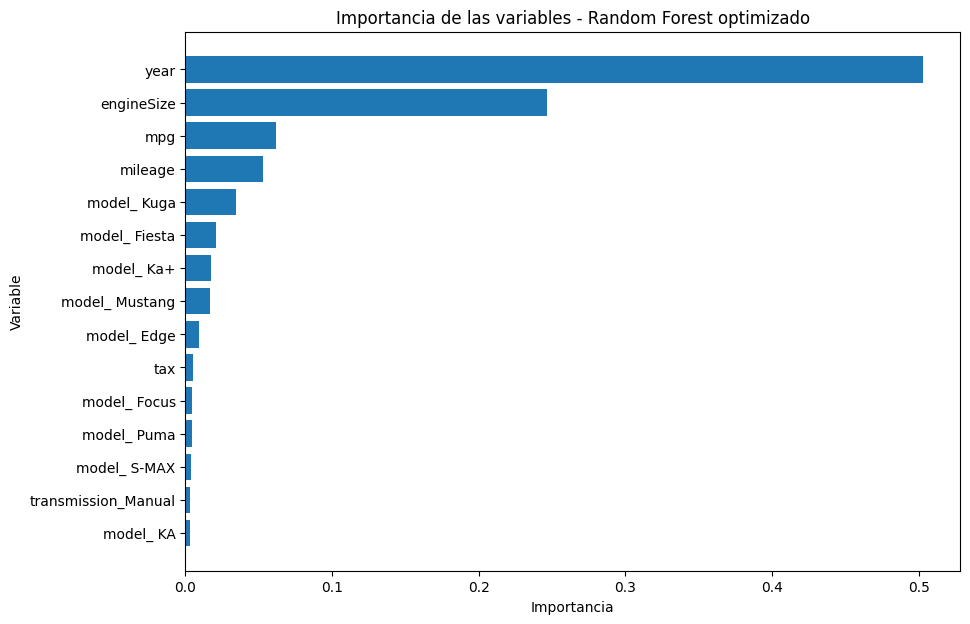

In [ ]:
top_importancias = importancias.head(15).sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    top_importancias.index,
    top_importancias.values
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de las variables - Random Forest optimizado")

plt.show()

### 🧠 Algo interesante al comparar con lo que hicimos antes
En nuestro análisis de correlaciones habíamos encontrado:<br>
year------       → correlación ≈ +0,636<br>
mileage---    → correlación ≈ -0,530<br>
engineSize → correlación ≈ +0,411<br>
mpg-------        → correlación ≈ -0,346<br>
tax-------        → correlación ≈ +0,406<br>
Y ahora Random Forest nos está mostrando algo diferente:<br>
year------        → importancia ≈ 0,50<br>
engineSize  → importancia ≈ 0,24<br>
mpg-------         → importancia ≈ 0,06<br>
mileage---     → importancia ≈ 0,05


Esto es muy importante para tu aprendizaje:<br>
Correlación e importancia de un modelo no son lo mismo.

<b>La correlación</b> mide una relación lineal entre una variable y price.<br>
<b>Random Forest</b>, en cambio, utiliza árboles y puede capturar relaciones no lineales e interacciones entre variables.<br>
Por eso no tenemos por qué obtener el mismo orden.<br>
⚠️ Y una precisión importante<br>
Que year tenga una importancia aproximada de 0,50 no significa:
"year determina el 50 % del precio."

Significa que, dentro de este Random Forest, las divisiones basadas en year contribuyen mucho a reducir el error de predicción.
Y tampoco significa causalidad.<br>
🎯 Lo que hemos conseguido con este paso<br>
Ahora tenemos tres formas diferentes de mirar nuestro dataset:
Correlación:<br>
#### ¿Existe una relación lineal entre la variable y el precio?

Coeficientes de Ridge/regresión:<br>
¿Cómo se relacionan las variables con la predicción dentro de un modelo lineal regularizado?

Importancia de Random Forest:<br>
¿Qué variables utiliza más el conjunto de árboles para realizar sus predicciones?

Son tres preguntas diferentes.<br>
Y eso es precisamente lo bueno de la práctica: no solamente estamos buscando el modelo que tenga mejor métrica, sino aprendiendo cómo analizar lo que hace el modelo.

In [ ]:
# Calcular los residuos del modelo optimizado de Random Forest
residuos_grid = y_test - y_pred_grid

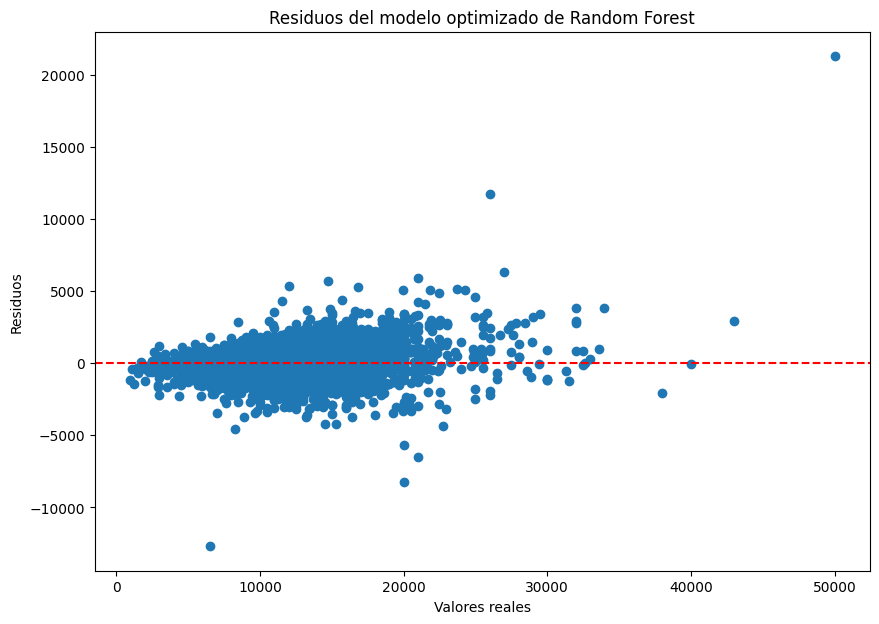

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test, residuos_grid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Valores reales")
plt.ylabel("Residuos")
plt.title("Residuos del modelo optimizado de Random Forest")
plt.show()

🔎 ¿Qué vemos?<br>
La mayor parte de los puntos está bastante concentrada alrededor de la línea roja de 0.<br>
Eso es una buena señal: significa que para una gran cantidad de coches, la diferencia entre el precio real y el predicho es relativamente pequeña.<br>
Además, vemos algunos errores extremos:
- aproximadamente +21.000 €
- aproximadamente −12.500 €
- otro alrededor de +12.000 €
- varios entre aproximadamente ±5.000 €

Por tanto, el modelo sigue teniendo algunos casos difíciles, aunque el error global haya mejorado.<br>
📌 Hay otra cosa interesante<br>
Observa que conforme aumenta el precio real hacia la derecha, la dispersión de los residuos parece aumentar.<br>
Es decir, para coches baratos los puntos están bastante concentrados, mientras que para coches más caros encontramos errores más grandes.
Esto puede indicar cierta heterocedasticidad: la magnitud del error no es completamente constante para todos los niveles de precio.<br>
No significa que el modelo sea inutilizable; simplemente nos indica que los coches de precios altos parecen ser más difíciles de predecir con la misma precisión.

In [ ]:
errores_grid = pd.DataFrame({
    "precio_real": y_test,
    "precio_predicho": y_pred_grid,
    "residuo": residuos_grid
})

errores_grid["error_absoluto"] = errores_grid["residuo"].abs()

errores_grid.sort_values(
    "error_absoluto",
    ascending=False
).head(10)

,precio_real,precio_predicho,residuo,error_absoluto
11913,49999,28691.014798,21307.985202,21307.985202
17726,6495,19185.179146,-12690.179146,12690.179146
2011,25998,14259.829116,11738.170884,11738.170884
8324,19995,28236.880711,-8241.880711,8241.880711
508,20990,27460.326564,-6470.326564,6470.326564
10660,27000,20666.806653,6333.193347,6333.193347
7841,20998,15073.424192,5924.575808,5924.575808
9974,14725,9038.986456,5686.013544,5686.013544
6150,20000,25669.441642,-5669.441642,5669.441642
2096,12000,6661.669422,5338.330578,5338.330578


# 🎯 Conclusión final del análisis de precios de coches

## 🚗 ¿Qué hemos aprendido?

Durante este proyecto hemos recorrido diferentes técnicas de **Machine Learning** para intentar predecir el precio de coches usados.

Comenzamos preparando y limpiando los datos, eliminando duplicados y tratando los valores nulos. Después analizamos las relaciones entre las variables y el precio mediante correlaciones y gráficos. 📊

---

## 🧹 1. Preparación de los datos

Realizamos diferentes pasos de preparación:

- 🔍 Comprobación de valores nulos.
- 🧹 Eliminación de registros duplicados.
- 📊 Separación de variables numéricas y categóricas.
- 🔤 Aplicación de **One-Hot Encoding** a las variables categóricas.
- ✂️ División de los datos en entrenamiento y prueba.

Esto nos permitió preparar los datos para utilizar diferentes modelos de Machine Learning.

---

## 📈 2. Modelos probados

Probamos diferentes algoritmos para comparar su comportamiento:

| Modelo | R² | RMSE |
|---|---:|---:|
| 📏 Regresión lineal | ≈ 0,8195 | ≈ 2.010 € |
| 📐 Regresión polinómica | ≈ 0,5518 | ≈ 3.170 € |
| 🧮 Ridge | ≈ 0,8190 | ≈ 2.015 € |
| 🌲 Random Forest | ≈ 0,9249 | ≈ 1.298 € |
| 🌳 Random Forest optimizado | **≈ 0,9318** | **≈ 1.237 €** |

---

## 🔎 3. ¿Qué observamos?

La **regresión polinómica de grado 2** no mejoró el modelo. Aunque aumentó considerablemente el número de características, el rendimiento fue peor.

La **regresión Ridge** obtuvo resultados muy similares a la regresión lineal. En nuestro caso, cambiar el valor de `alpha` produjo modificaciones muy pequeñas en las métricas.

🌲 **Random Forest** consiguió capturar relaciones más complejas y obtuvo un rendimiento superior al de los modelos lineales.

Posteriormente utilizamos **Cross-Validation** y después **GridSearchCV** para ajustar los hiperparámetros del Random Forest.

---

## ⚙️ 4. Optimización del modelo

Mediante `GridSearchCV` buscamos diferentes combinaciones de:

- 🌳 `n_estimators`
- 🌲 `max_depth`
- 🔀 `min_samples_split`

La validación cruzada utilizada durante la búsqueda obtuvo un:

**R² medio ≈ 0,9322**

Posteriormente evaluamos el modelo optimizado sobre nuestro conjunto de prueba:

- 🎯 **R² = 0,9318**
- 💰 **RMSE ≈ 1.237 €**
- 📉 **MSE ≈ 1.530.041**

El RMSE indica el tamaño típico del error de predicción según esta métrica, expresado en euros.

---

## 🔬 5. Importancia de las variables

Analizamos también qué variables utiliza más el Random Forest para realizar sus predicciones.

Las características que aparecieron con mayor importancia fueron principalmente:

🥇 `year`  
🥈 `engineSize`  
🥉 `mpg`  
➡️ `mileage`

También tuvieron importancia algunas categorías de `model`, como `Kuga`, `Fiesta`, `Mustang`, `Edge`, etc.

⚠️ La importancia de una variable en Random Forest **no significa que esa variable cause directamente el precio**. Representa su contribución relativa dentro de las decisiones de los árboles del modelo.

---

## 🧪 6. Análisis de residuos

También analizamos los residuos:

```text
residuo = precio_real - precio_predicho

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
variables_numericas = [
    "year",
    "mileage",
    "tax",
    "mpg",
    "engineSize"
]

variables_categoricas = [
    "model",
    "transmission",
    "fuelType"
]
preprocesador = ColumnTransformer([
    ("numericas", "passthrough", variables_numericas),
    # handle_unknown es importante para evitar errores con categorías desconocidas en el conjunto de prueba
    ("categoricas", OneHotEncoder(handle_unknown="ignore"), variables_categoricas)
])

In [ ]:
modelo_final = Pipeline([
    ("preprocesamiento", preprocesador),
    ("random_forest", RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=15,
        random_state=42,
        n_jobs=1
    ))
])

                 X original
                     ↓
           ┌──────────────────┐
           │ ColumnTransformer│
           └────────┬─────────┘
                    ↓
       ┌────────────┴────────────┐
       ↓                         ↓
  Numéricas------------------Categóricas<br>
 -----↓-------------------------↓<br>
passthrough-----------------OneHotEncoder<br>
       └────────────┬────────────┘<br>
              ------↓<br>
        -------Random Forest<br>
              ------↓<br>
        ----------- Precio

Pero aquí hay un detalle: X_train que tienes ahora mismo procede de df_encoded. Para este nuevo Pipeline, queremos que X_train proceda del df original, porque el propio Pipeline hará el OneHotEncoder.
Por tanto, en la siguiente celda hacemos solamente:

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Fit modelo_final on the training data
y_pred_final = modelo_final.fit(X_train_final, y_train_final).predict(X_test_final)

In [ ]:
r2_final = r2_score(y_test_final, y_pred_final)
mse_final = mean_squared_error(y_test_final, y_pred_final)
rmse_final = mse_final ** 0.5

print("R²:", r2_final)
print("MSE:", mse_final)
print("RMSE:", rmse_final)

R²: 0.9324591796920572
MSE: 1514471.4000857952
RMSE: 1230.6386147386222


<b>Perfecto. 👍 Y sí:</b> a partir de ahora, cualquier esquema con flechas o explicación visual te lo pondré dentro de un bloque Markdown, para que puedas copiarlo directamente a una celda Markdown de tu .ipynb sin que se desordene.

### 💾 Paso 12 — Guardar nuestro modelo

In [ ]:
import joblib

In [ ]:
# Guardar el modelo final en un archivo .pkl
joblib.dump(modelo_final, "modelo_coches.pkl")

['modelo_coches.pkl']

# 💾 Guardado del modelo

Una vez entrenado y evaluado nuestro Pipeline, podemos guardar el modelo completo para utilizarlo posteriormente sin tener que volver a entrenarlo.

```text
Datos originales
      ↓
ColumnTransformer
      ↓
OneHotEncoder
      ↓
Random Forest
      ↓
Modelo entrenado
      ↓
💾 modelo_coches.pkl


### 🚀 Después de esto

El siguiente paso será **aprender a cargar ese `.pkl` y utilizarlo para realizar una predicción con un coche nuevo**.

Ahí es donde nuestro notebook empieza a convertirse realmente en un **programa de Machine Learning**.